## Módulo 3 — Sistema de Recomendación de Destinos (Google Reviews Europa)

In [1]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import kagglehub

# Semilla para reproducibilidad
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

c:\Users\srand\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Carga de datos

In [2]:
path = kagglehub.dataset_download("ishbhms/travel-review-ratings")
df_europa = pd.read_csv(os.path.join(path, "google_review_ratings.csv"))

# Nombres reales de las categorías
category_names = {
    'Category 1':  'churches',
    'Category 2':  'resorts',
    'Category 3':  'beaches',
    'Category 4':  'parks',
    'Category 5':  'theatres',
    'Category 6':  'museums',
    'Category 7':  'malls',
    'Category 8':  'zoo',
    'Category 9':  'restaurants',
    'Category 10': 'pubs_bars',
    'Category 11': 'local_services',
    'Category 12': 'burger_pizza',
    'Category 13': 'hotels',
    'Category 14': 'juice_bars',
    'Category 15': 'art_galleries',
    'Category 16': 'dance_clubs',
    'Category 17': 'swimming_pools',
    'Category 18': 'gyms',
    'Category 19': 'bakeries',
    'Category 20': 'beauty_spas',
    'Category 21': 'cafes',
    'Category 22': 'viewpoints',
    'Category 23': 'monuments',
    'Category 24': 'gardens'
}

df_europa = df_europa.rename(columns=category_names)
df_europa = df_europa.drop(columns=['Unnamed: 25'], errors='ignore')

print(f"Shape: {df_europa.shape}")
print(f"Columnas: {df_europa.columns.tolist()}")
print(f"\nPrimeras 3 filas:")
print(df_europa.head(3))

Shape: (5456, 25)
Columnas: ['User', 'churches', 'resorts', 'beaches', 'parks', 'theatres', 'museums', 'malls', 'zoo', 'restaurants', 'pubs_bars', 'local_services', 'burger_pizza', 'hotels', 'juice_bars', 'art_galleries', 'dance_clubs', 'swimming_pools', 'gyms', 'bakeries', 'beauty_spas', 'cafes', 'viewpoints', 'monuments', 'gardens']

Primeras 3 filas:
     User  churches  resorts  beaches  parks  theatres  museums  malls   zoo  \
0  User 1       0.0      0.0     3.63   3.65       5.0     2.92    5.0  2.35   
1  User 2       0.0      0.0     3.63   3.65       5.0     2.92    5.0  2.64   
2  User 3       0.0      0.0     3.63   3.63       5.0     2.92    5.0  2.64   

   restaurants  ...  art_galleries dance_clubs  swimming_pools  gyms  \
0         2.33  ...           1.74        0.59             0.5   0.0   
1         2.33  ...           1.74        0.59             0.5   0.0   
2         2.33  ...           1.74        0.59             0.5   0.0   

   bakeries  beauty_spas  cafes  v

### Preprocesamiento

In [3]:
### Preprocesamiento

# Limpiar Category 11 (local_services) que es string
df_europa['local_services'] = pd.to_numeric(df_europa['local_services'], errors='coerce')

# Rellenar nulos con la media de cada columna
cat_cols = list(category_names.values())
df_europa[cat_cols] = df_europa[cat_cols].fillna(df_europa[cat_cols].mean())

# Crear user_id numérico
df_europa['user_id'] = range(len(df_europa))

print(f"Nulos tras limpieza: {df_europa[cat_cols].isnull().sum().sum()}")
print(f"Usuarios totales: {len(df_europa)}")
print(f"\nEstadísticas de ratings:")
print(df_europa[cat_cols].describe().round(2))

Nulos tras limpieza: 0
Usuarios totales: 5456

Estadísticas de ratings:
       churches  resorts  beaches    parks  theatres  museums    malls  \
count   5456.00  5456.00  5456.00  5456.00   5456.00  5456.00  5456.00   
mean       1.46     2.32     2.49     2.80      2.96     2.89     3.35   
std        0.83     1.42     1.25     1.31      1.34     1.28     1.41   
min        0.00     0.00     0.00     0.83      1.12     1.11     1.12   
25%        0.92     1.36     1.54     1.73      1.77     1.79     1.93   
50%        1.34     1.90     2.06     2.46      2.67     2.68     3.23   
75%        1.81     2.68     2.74     4.09      4.31     3.84     5.00   
max        5.00     5.00     5.00     5.00      5.00     5.00     5.00   

           zoo  restaurants  pubs_bars  ...  art_galleries  dance_clubs  \
count  5456.00      5456.00    5456.00  ...        5456.00      5456.00   
mean      2.54         3.13       2.83  ...           2.21         1.19   
std       1.11         1.36       1.

### Construcción del dataset — formato usuario-categoría-rating

In [4]:
# Convertir de formato ancho a formato largo
# Cada fila = un usuario, una categoría, un rating
df_long = df_europa.melt(
    id_vars=['user_id', 'User'],
    value_vars=cat_cols,
    var_name='categoria',
    value_name='rating'
)

# Crear ID numérico para categorías
cat_id_map  = {cat: idx for idx, cat in enumerate(cat_cols)}
df_long['cat_id'] = df_long['categoria'].map(cat_id_map)

# Label: rating >= 3.5 es positivo (le gustó)
df_long['label'] = (df_long['rating'] >= 3.5).astype(float)

print(f"Total interacciones: {len(df_long)}")
print(f"Usuarios únicos: {df_long['user_id'].nunique()}")
print(f"Categorías únicas: {df_long['cat_id'].nunique()}")
print(f"Promedio interacciones por usuario: {len(df_long)/df_long['user_id'].nunique():.1f}")
print(f"\nDistribución de labels:")
print(df_long['label'].value_counts())
print(f"Positivos: {df_long['label'].mean():.2%}")

Total interacciones: 130944
Usuarios únicos: 5456
Categorías únicas: 24
Promedio interacciones por usuario: 24.0

Distribución de labels:
label
0.0    107568
1.0     23376
Name: count, dtype: int64
Positivos: 17.85%


### Split train/test

In [5]:
train_df, test_df = train_test_split(df_long, test_size=0.2, random_state=42)

print(f"Train: {len(train_df)} | Test: {len(test_df)}")
print(f"Positivos en train: {train_df['label'].mean():.2%}")

Train: 104755 | Test: 26189
Positivos en train: 17.85%


### Dataset y DataLoader de PyTorch

In [6]:
# Features del usuario: sus ratings en todas las categorías
user_features = df_europa.set_index('user_id')[cat_cols].values
scaler = MinMaxScaler()
user_features = scaler.fit_transform(user_features)

# Features de la categoría: one-hot
n_cats = len(cat_cols)

class TravelDataset(Dataset):
    def __init__(self, df):
        self.user_ids  = torch.tensor(df['user_id'].values, dtype=torch.long)
        self.cat_ids   = torch.tensor(df['cat_id'].values, dtype=torch.long)
        self.user_feat = torch.tensor(
            user_features[df['user_id'].values], dtype=torch.float32
        )
        # One-hot de la categoría
        cat_onehot = np.eye(n_cats)[df['cat_id'].values]
        self.cat_feat = torch.tensor(cat_onehot, dtype=torch.float32)
        self.labels   = torch.tensor(df['label'].values, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (self.user_ids[idx], self.cat_ids[idx],
                self.user_feat[idx], self.cat_feat[idx],
                self.labels[idx])

train_dataset = TravelDataset(train_df)
test_dataset  = TravelDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)

print(f"Batches train: {len(train_loader)} | Batches test: {len(test_loader)}")

Batches train: 410 | Batches test: 103


### Arquitectura de la red neuronal

In [7]:
class HybridRecommender(nn.Module):
    def __init__(self, n_user_feats, n_cat_feats):
        super().__init__()

        input_dim = n_user_feats + n_cat_feats
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, user_id, cat_id, user_feat, cat_feat):
        x = torch.cat([user_feat, cat_feat], dim=1)
        return self.layers(x).squeeze(1)

### Inicialización del modelo, loss y optimizador

In [8]:
### Inicialización del modelo, loss y optimizador

torch.manual_seed(42)

n_user_feats = len(cat_cols)
n_cat_feats  = n_cats

pct_pos    = train_df['label'].mean()
pct_neg    = 1 - pct_pos
pos_weight = torch.tensor([pct_neg / pct_pos])

print(f"Features usuario: {n_user_feats} | Features categoría: {n_cat_feats}")
print(f"Positivos: {pct_pos:.2%} | Negativos: {pct_neg:.2%}")
print(f"pos_weight: {pos_weight.item():.4f}")

model     = HybridRecommender(n_user_feats, n_cat_feats)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-3)

print(f"Parámetros totales: {sum(p.numel() for p in model.parameters())}")

Features usuario: 24 | Features categoría: 24
Positivos: 17.85% | Negativos: 82.15%
pos_weight: 4.6031
Parámetros totales: 5441


### Loop de entrenamiento

In [ ]:
### Loop de entrenamiento

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    for user_id, cat_id, user_feat, cat_feat, labels in loader:
        optimizer.zero_grad()
        preds = model(user_id, cat_id, user_feat, cat_feat)
        loss  = criterion(preds, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for user_id, cat_id, user_feat, cat_feat, labels in loader:
            preds = model(user_id, cat_id, user_feat, cat_feat)
            loss  = criterion(preds, labels)
            total_loss += loss.item()
    return total_loss / len(loader)

EPOCHS            = 100
PATIENCE          = 10
best_loss         = float('inf')
epochs_sin_mejora = 0
train_losses      = []
test_losses       = []

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, criterion, optimizer)
    test_loss  = eval_epoch(model, test_loader, criterion)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")

    if test_loss < best_loss:
        best_loss         = test_loss
        epochs_sin_mejora = 0
        torch.save(model.state_dict(), "best_model_recom.pth")
        print(f"  -> Modelo guardado (test loss: {best_loss:.4f})")
    else:
        epochs_sin_mejora += 1
        if epochs_sin_mejora >= PATIENCE:
            print(f"\nEarly stopping en época {epoch+1}. Mejor test loss: {best_loss:.4f}")
            break

Epoch 01 | Train Loss: 0.7370 | Test Loss: 0.3266
  -> Modelo guardado (test loss: 0.3266)
Epoch 02 | Train Loss: 0.4069 | Test Loss: 0.1700
  -> Modelo guardado (test loss: 0.1700)
Epoch 03 | Train Loss: 0.3172 | Test Loss: 0.1258
  -> Modelo guardado (test loss: 0.1258)
Epoch 04 | Train Loss: 0.2631 | Test Loss: 0.1109
  -> Modelo guardado (test loss: 0.1109)
Epoch 05 | Train Loss: 0.2272 | Test Loss: 0.0888
  -> Modelo guardado (test loss: 0.0888)


### Evaluación del modelo


In [ ]:
model.load_state_dict(torch.load("best_model_recom.pth"))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for user_id, cat_id, user_feat, cat_feat, labels in test_loader:
        logits = model(user_id, cat_id, user_feat, cat_feat)
        probs  = torch.sigmoid(logits)
        preds  = (probs >= 0.5).float()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

print(f"Muestras evaluadas: {len(all_labels)}")
print(f"Accuracy:  {accuracy_score(all_labels, all_preds):.4f}")
print(f"Precision: {precision_score(all_labels, all_preds):.4f}")
print(f"Recall:    {recall_score(all_labels, all_preds):.4f}")
print(f"F1:        {f1_score(all_labels, all_preds):.4f}")

Muestras evaluadas: 26189
Accuracy:  0.9938
Precision: 0.9695
Recall:    0.9968
F1:        0.9829


### Ajuste de umbral

In [ ]:
model.load_state_dict(torch.load("best_model_recom.pth"))
model.eval()

all_probs  = []
all_labels = []

with torch.no_grad():
    for user_id, cat_id, user_feat, cat_feat, labels in test_loader:
        logits = model(user_id, cat_id, user_feat, cat_feat)
        probs  = torch.sigmoid(logits)
        all_probs.extend(probs.tolist())
        all_labels.extend(labels.tolist())

print(f"{'Umbral':<10} {'Acc':<10} {'Prec':<10} {'Rec':<10} {'F1':<10}")
print("-" * 50)

umbrales   = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]
resultados = []

for umbral in umbrales:
    preds = [1.0 if p >= umbral else 0.0 for p in all_probs]
    acc   = accuracy_score(all_labels, preds)
    prec  = precision_score(all_labels, preds, zero_division=0)
    rec   = recall_score(all_labels, preds, zero_division=0)
    f1    = f1_score(all_labels, preds, zero_division=0)
    resultados.append({'umbral': umbral, 'f1': f1})
    print(f"{umbral:<10} {acc:<10.4f} {prec:<10.4f} {rec:<10.4f} {f1:<10.4f}")

print("\nDistribución de predicciones (umbral 0.5):")
preds_05 = [1.0 if p >= 0.5 else 0.0 for p in all_probs]
print(f"  Predice positivo: {sum(preds_05)} ({sum(preds_05)/len(preds_05):.2%})")
print(f"  Predice negativo: {len(preds_05)-sum(preds_05)} ({(len(preds_05)-sum(preds_05))/len(preds_05):.2%})")
print(f"  Real positivo:    {sum(all_labels)} ({sum(all_labels)/len(all_labels):.2%})")

# Selección automática del umbral óptimo
mejor = max(resultados, key=lambda x: x['f1'])
UMBRAL_OPTIMO = mejor['umbral']
print(f"\nUmbral óptimo seleccionado automáticamente: {UMBRAL_OPTIMO} (mejor F1: {mejor['f1']:.4f})")

Umbral     Acc        Prec       Rec        F1        
--------------------------------------------------
0.3        0.9886     0.9417     0.9981     0.9691    
0.35       0.9904     0.9505     0.9981     0.9737    
0.4        0.9918     0.9581     0.9976     0.9775    
0.45       0.9929     0.9645     0.9972     0.9806    
0.5        0.9938     0.9695     0.9968     0.9829    
0.55       0.9944     0.9733     0.9959     0.9845    
0.6        0.9953     0.9788     0.9955     0.9871    

Distribución de predicciones (umbral 0.5):
  Predice positivo: 4812.0 (18.37%)
  Predice negativo: 21377.0 (81.63%)
  Real positivo:    4680.0 (17.87%)

Umbral óptimo seleccionado automáticamente: 0.6 (mejor F1: 0.9871)


### Función de recomendación Top-K

In [ ]:
### Función de recomendación Top-K

def recomendar_categorias(user_id, top_k=5):
    if user_id >= len(df_europa):
        print(f"Usuario {user_id} no encontrado.")
        return None

    model.load_state_dict(torch.load("best_model_recom.pth"))
    model.eval()

    # Features del usuario
    user_feat = torch.tensor(
        user_features[user_id:user_id+1], dtype=torch.float32
    ).repeat(n_cats, 1)

    # One-hot de todas las categorías
    cat_onehot = torch.tensor(np.eye(n_cats), dtype=torch.float32)

    # Índices dummy
    user_ids = torch.zeros(n_cats, dtype=torch.long)
    cat_ids  = torch.arange(n_cats, dtype=torch.long)

    with torch.no_grad():
        logits = model(user_ids, cat_ids, user_feat, cat_onehot)
        probs  = torch.sigmoid(logits).numpy()

    resultado = pd.DataFrame({
        'categoria':   cat_cols,
        'score':       probs,
        'rating_real': df_europa.iloc[user_id][cat_cols].values
    })
    resultado = resultado.sort_values('score', ascending=False).head(top_k)

    usuario_nombre = df_europa.iloc[user_id]['User']
    print(f"\nTop-{top_k} categorías recomendadas para {usuario_nombre}:")
    print(resultado[['categoria', 'rating_real', 'score']].to_string(index=False))
    return resultado

# Probar con usuarios de perfiles distintos
usuarios_demo = {
    'Perfil Playa':      122,
    'Perfil Cultural':   61,
    'Perfil Gastrónomo': 121
}

for perfil, uid in usuarios_demo.items():
    print(f"\n--- {perfil} ---")
    recomendar_categorias(uid, top_k=5)


--- Perfil Playa ---

Top-5 categorías recomendadas para User 123:
 categoria rating_real    score
       zoo         5.0 0.998863
   beaches         5.0 0.998775
   resorts         5.0 0.998678
juice_bars         5.0 0.998483
    hotels         5.0 0.996484

--- Perfil Cultural ---

Top-5 categorías recomendadas para User 62:
  categoria rating_real    score
      parks         5.0 0.990318
    museums         5.0 0.979976
   theatres        3.82 0.940000
restaurants        2.86 0.093898
        zoo        2.94 0.005621

--- Perfil Gastrónomo ---

Top-5 categorías recomendadas para User 122:
  categoria rating_real    score
restaurants         5.0 0.999914
        zoo         5.0 0.999154
      malls        4.11 0.998732
 juice_bars         5.0 0.998149
    resorts         5.0 0.996880


### Gráficas

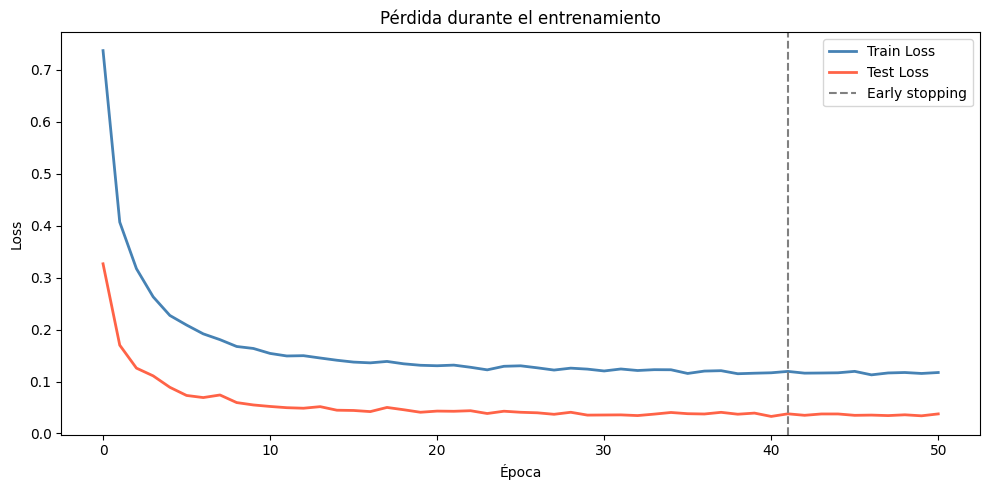


Top-5 categorías recomendadas para User 123:
 categoria rating_real    score
       zoo         5.0 0.998863
   beaches         5.0 0.998775
   resorts         5.0 0.998678
juice_bars         5.0 0.998483
    hotels         5.0 0.996484

Top-5 categorías recomendadas para User 62:
  categoria rating_real    score
      parks         5.0 0.990318
    museums         5.0 0.979976
   theatres        3.82 0.940000
restaurants        2.86 0.093898
        zoo        2.94 0.005621

Top-5 categorías recomendadas para User 122:
  categoria rating_real    score
restaurants         5.0 0.999914
        zoo         5.0 0.999154
      malls        4.11 0.998732
 juice_bars         5.0 0.998149
    resorts         5.0 0.996880


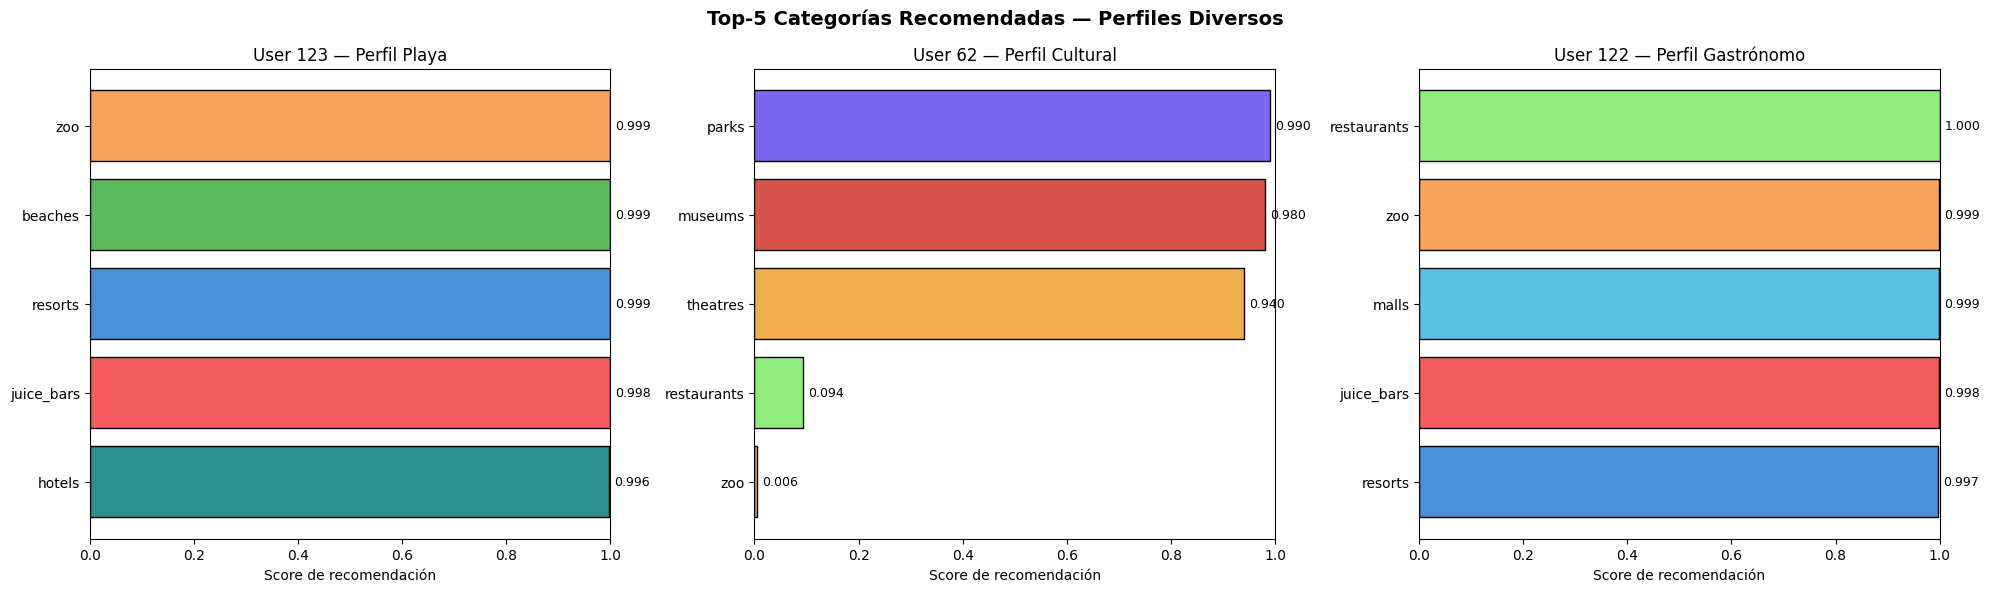

In [ ]:
# 1. Pérdida por época
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='steelblue', linewidth=2)
plt.plot(test_losses,  label='Test Loss',  color='tomato',    linewidth=2)
plt.axvline(x=len(train_losses)-PATIENCE, color='gray',
            linestyle='--', label='Early stopping')
plt.title("Pérdida durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

# 2. Visualización de recomendaciones por usuario
color_map = {
    'churches': '#E07B54', 'resorts': '#4A90D9', 'beaches': '#5CB85C',
    'parks': '#7B68EE', 'theatres': '#F0AD4E', 'museums': '#D9534F',
    'malls': '#5BC0DE', 'zoo': '#F7A35C', 'restaurants': '#90ED7D',
    'pubs_bars': '#8085E9', 'local_services': '#F15C80',
    'burger_pizza': '#E4D354', 'hotels': '#2B908F', 'juice_bars': '#F45B5B',
    'art_galleries': '#91E8E1', 'dance_clubs': '#A57DD1',
    'swimming_pools': '#4A90D9', 'gyms': '#E07B54', 'bakeries': '#F0AD4E',
    'beauty_spas': '#5CB85C', 'cafes': '#D9534F', 'viewpoints': '#7B68EE',
    'monuments': '#5BC0DE', 'gardens': '#90ED7D'
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Top-5 Categorías Recomendadas — Perfiles Diversos",
             fontsize=14, fontweight='bold')

usuarios_demo = {
    'Perfil Playa':      122,
    'Perfil Cultural':   61,
    'Perfil Gastrónomo': 121
}

for ax, (perfil, uid) in zip(axes, usuarios_demo.items()):
    rec = recomendar_categorias(uid, top_k=5)
    colores = [color_map.get(c, '#999999') for c in rec['categoria'].values]
    bars    = ax.barh(rec['categoria'].values, rec['score'].values,
                      color=colores, edgecolor='black')
    ax.set_xlim(0, 1)
    ax.set_xlabel("Score de recomendación")
    ax.set_title(f"{df_europa.iloc[uid]['User']} — {perfil}")
    ax.invert_yaxis()
    for bar, score in zip(bars, rec['score'].values):
        ax.text(bar.get_width() + 0.01,
                bar.get_y() + bar.get_height()/2,
                f"{score:.3f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Prueba



In [ ]:
path2 = kagglehub.dataset_download("cosmox23/popular-tourist-destinations-and-their-features")
print("Archivos:", os.listdir(path2))

Archivos: ['Tourist_Destinations.csv']


In [ ]:
df_sitios = pd.read_csv(os.path.join(path2, "Tourist_Destinations.csv"))

print(f"Shape: {df_sitios.shape}")
print(f"\nColumnas: {df_sitios.columns.tolist()}")
print(f"\nPrimeras 5 filas:")
print(df_sitios.head())
print(f"\nCategorías únicas:")
print(df_sitios.iloc[:, 3].unique())  # columna de tipo/categoría

Shape: (2000, 9)

Columnas: ['Destination Name', 'Country', 'Continent', 'Type', 'Avg Cost (USD/day)', 'Best Season', 'Avg Rating', 'Annual Visitors (M)', 'UNESCO Site']

Primeras 5 filas:
  Destination Name       Country      Continent       Type  \
0    Serene Temple       Morocco         Africa      Beach   
1    Sacred Valley       Germany         Europe  Religious   
2    Serene Temple  South Africa         Africa  Adventure   
3     Sacred Plaza     Australia        Oceania     Nature   
4     Golden Ruins        Mexico  North America  Adventure   

   Avg Cost (USD/day) Best Season  Avg Rating  Annual Visitors (M) UNESCO Site  
0              174.84      Summer         4.5                 7.45          No  
1               94.41      Summer         4.6                 1.98          No  
2              228.96      Summer         4.7                 0.70         Yes  
3              120.96      Summer         4.3                 2.24          No  
4              162.10      Spring

### Sistema en cascada — Recomendación de sitios turísticos

In [ ]:
### Sistema en cascada — Recomendación de sitios turísticos

# Cargar dataset de sitios
path2     = kagglehub.dataset_download("cosmox23/popular-tourist-destinations-and-their-features")
df_sitios = pd.read_csv(os.path.join(path2, "Tourist_Destinations.csv"))

# Mapeo de categorías Europa → categorías sitios
mapeo_categorias = {
    'beaches':        'Beach',
    'resorts':        'Beach',
    'parks':          'Nature',
    'gardens':        'Nature',
    'zoo':            'Adventure',
    'dance_clubs':    'Adventure',
    'swimming_pools': 'Adventure',
    'gyms':           'Adventure',
    'churches':       'Religious',
    'monuments':      'Religious',
    'museums':        'Historical',
    'art_galleries':  'Historical',
    'viewpoints':     'Historical',
    'theatres':       'City',
    'malls':          'City',
    'restaurants':    'City',
    'cafes':          'City',
    'pubs_bars':      'City',
    'hotels':         'City',
    'local_services': 'City',
    'burger_pizza':   'City',
    'juice_bars':     'City',
    'bakeries':       'City',
    'beauty_spas':    'City'
}

def recomendar_sitios(user_id, top_k_cats=3, top_k_sitios=5):
    if user_id >= len(df_europa):
        print(f"Usuario {user_id} no encontrado.")
        return None

    model.load_state_dict(torch.load("best_model_recom.pth"))
    model.eval()

    user_feat  = torch.tensor(
        user_features[user_id:user_id+1], dtype=torch.float32
    ).repeat(n_cats, 1)
    cat_onehot = torch.tensor(np.eye(n_cats), dtype=torch.float32)
    user_ids   = torch.zeros(n_cats, dtype=torch.long)
    cat_ids    = torch.arange(n_cats, dtype=torch.long)

    with torch.no_grad():
        logits = model(user_ids, cat_ids, user_feat, cat_onehot)
        probs  = torch.sigmoid(logits).numpy()

    df_probs     = pd.DataFrame({'categoria': cat_cols, 'score': probs})
    top_cats     = df_probs.nlargest(top_k_cats, 'score')['categoria'].tolist()
    tipos_sitios = list(set([
        mapeo_categorias[c] for c in top_cats if c in mapeo_categorias
    ]))

    sitios     = df_sitios[df_sitios['Type'].isin(tipos_sitios)]
    sitios_top = sitios.sort_values('Avg Rating', ascending=False).head(top_k_sitios)

    usuario_nombre = df_europa.iloc[user_id]['User']

    # Formato limpio y profesional
    print(f"\n{'RECOMENDACIÓN DE VIAJE':>40}")
    print(f"  Usuario        : {usuario_nombre}")
    print(f"  Intereses top  : {', '.join(top_cats)}")
    print(f"  Tipos de sitio : {', '.join(tipos_sitios)}")
    print(f"\n  {'#':<4} {'Destino':<22} {'País':<15} {'Tipo':<12} {'Rating':<8} {'Costo/día'}")
    print(f"  {'─'*75}")
    for i, (_, row) in enumerate(sitios_top.iterrows(), 1):
        print(f"  {i:<4} {row['Destination Name']:<22} {row['Country']:<15} "
              f"{row['Type']:<12} {row['Avg Rating']:<8} ${row['Avg Cost (USD/day)']:.2f}")
    print(f"  {'─'*75}\n")

    return sitios_top

# Probar con los 3 perfiles
usuarios_demo = {
    'Perfil Playa':      122,
    'Perfil Cultural':   61,
    'Perfil Gastrónomo': 121
}

for perfil, uid in usuarios_demo.items():
    print(f"\n  [ {perfil.upper()} ]")
    recomendar_sitios(uid, top_k_cats=3, top_k_sitios=5)






  [ PERFIL PLAYA ]

                  RECOMENDACIÓN DE VIAJE
  Usuario        : User 123
  Intereses top  : zoo, beaches, resorts
  Tipos de sitio : Beach, Adventure

  #    Destino                País            Tipo         Rating   Costo/día
  ───────────────────────────────────────────────────────────────────────────
  1    Grand Ruins            Vietnam         Beach        5.0      $168.86
  2    Crystal Park           Canada          Beach        5.0      $163.43
  3    Serene Falls           Australia       Beach        5.0      $108.24
  4    Mystic Falls           Thailand        Adventure    5.0      $127.32
  5    Golden Beach           Greece          Adventure    5.0      $252.17
  ───────────────────────────────────────────────────────────────────────────


  [ PERFIL CULTURAL ]

                  RECOMENDACIÓN DE VIAJE
  Usuario        : User 62
  Intereses top  : parks, museums, theatres
  Tipos de sitio : City, Historical, Nature

  #    Destino                País  